Proyecto_Analitica
Limpieza y organización de datos.

PASO 1: Importar librerias y cargar base de datos

In [7]:
import pandas as pd
import numpy as np

In [8]:
df_financiacion = pd.read_excel('/Users/yedisoncuervo/Downloads/BD taller clasificación (2) (2).xlsx')
df_financiacion.head(5)

,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1004991730,ASALARIADO,NUEVO,30,FEMENINO,748,0.6850,72,3289800.0,2430508.51,0.361093,2379693,0
1,1005097331,INDEPENDIENTE,NUEVO,46,MASCULINO,670,0.2783,60,2425440.0,1621788.08,0.948770,847046,0
2,1005120587,INDEPENDIENTE,USADO,39,MASCULINO,752,1.0000,60,30000000.0,3614018.63,12.009213,2197145,0
3,1005152562,ASALARIADO,USADO,38,FEMENINO,758,1.0000,84,1631331.0,1725244.99,-0.068706,1366896,0
4,1005153782,INDEPENDIENTE,NUEVO,60,FEMENINO,846,0.6596,72,20907400.0,3439341.88,13.004595,1343222,0


PASO 2: Informacion general de la base de datos.

In [9]:
df_financiacion.info()

<class 'pandas.DataFrame'>
RangeIndex: 21091 entries, 0 to 21090
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Caso                    21091 non-null  int64  
 1   Perfil                  21091 non-null  str    
 2   Estado                  21091 non-null  str    
 3   Edad                    21091 non-null  int64  
 4   Genero                  21091 non-null  str    
 5   ScoreCrediticio         21091 non-null  int64  
 6   PorcentajeFinanciacion  21091 non-null  float64
 7   Plazo                   21091 non-null  int64  
 8   IngresoEstimado         21063 non-null  float64
 9   Gastos                  21091 non-null  float64
 10  CapacidadDePago         21063 non-null  float64
 11  ValorCuotaMensual       21091 non-null  int64  
 12  M3_30AC                 21091 non-null  int64  
dtypes: float64(4), int64(6), str(3)
memory usage: 2.1 MB


PASO 3: Validar si hay datos, faltantes, nulos Duplicados.
IMPORTANTE! Realizaremos si la cantidad de datos faltantes en una columna "Variable" supera eld 40% dicha columna será eliminada. 

In [10]:
# ── 4. Datos nulos ────────────────────────────────────────────────────────
print("DATOS NULOS")
nulos = df_financiacion.isnull().sum()
pct   = (nulos / len(df_financiacion) * 100).round(2)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
resumen_nulos = resumen_nulos[resumen_nulos['Nulos'] > 0]
if resumen_nulos.empty:
    print("No hay datos nulos.")
else:
    print(resumen_nulos)

DATOS NULOS
                 Nulos  Porcentaje (%)
IngresoEstimado     28            0.13
CapacidadDePago     28            0.13


Dado que el porcentaje  de los datos nulos de las variables (IngresosEstimado/CapacidadDePago) Es de tan solo el 0.13% se procede a eliminar estas filas de nuestra BD.

In [11]:
# Eliminar filas con datos nulos
df_financiacion = df_financiacion.dropna()

In [12]:
# Verificar que quedaron cero nulos
print(f"Filas después de eliminar nulos: {len(df_financiacion)}")
print(f"Nulos restantes: {df_financiacion.isnull().sum().sum()}")

Filas después de eliminar nulos: 21063
Nulos restantes: 0


In [13]:
# ── 5. Datos duplicados ───────────────────────────────────────────────────
print("DATOS DUPLICADOS")
duplicados = df_financiacion.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

DATOS DUPLICADOS
Filas duplicadas: 0


In [14]:
# ── 6. Estadísticas descriptivas ──────────────────────────────────────────
print("ESTADÍSTICAS DESCRIPTIVAS")
print(df_financiacion.describe())

ESTADÍSTICAS DESCRIPTIVAS
               Caso          Edad  ScoreCrediticio  PorcentajeFinanciacion  \
count  2.106300e+04  21063.000000     21063.000000            21063.000000   
mean   1.006178e+09     44.542563       782.361724                0.743488   
std    3.264530e+05     12.744980        85.314167                0.246626   
min    1.004992e+09     19.000000       343.000000                0.100000   
25%    1.005912e+09     34.000000       726.000000                0.552200   
50%    1.006159e+09     43.000000       783.000000                0.800000   
75%    1.006453e+09     54.000000       838.000000                1.000000   
max    1.006786e+09     75.000000       999.000000                1.067000   

              Plazo  IngresoEstimado        Gastos  CapacidadDePago  \
count  21063.000000     2.106300e+04  2.106300e+04     2.106300e+04   
mean      60.633101     5.018901e+06  1.142708e+08    -8.077237e+01   
std       12.497081     5.955286e+06  1.624658e+10     1.1

## IMPORTANTE! 
Con este codigo podremos saber si nuestra variable objetivo esta desbalanceada o no. 

In [15]:
# ── 7. Distribución de la variable objetivo ───────────────────────────────
print("DISTRIBUCIÓN VARIABLE OBJETIVO (M3_30AC)")
conteo = df_financiacion['M3_30AC'].value_counts()
pct_target = (conteo / len(df_financiacion) * 100).round(2)
print(pd.DataFrame({'Conteo': conteo, 'Porcentaje (%)': pct_target}))

DISTRIBUCIÓN VARIABLE OBJETIVO (M3_30AC)
         Conteo  Porcentaje (%)
M3_30AC                        
0         20228           96.04
1           835            3.96


PASO 4: 
## Balanceo de clases

Una vez depurada la base de datos — sin valores nulos, faltantes ni duplicados — se identificó 
un desbalance severo en la variable objetivo `M3_30AC`: el 96% de los registros corresponde 
a clientes sin mora (clase 0) y solo el 4% a clientes con mora (clase 1), lo que representa 
una proporción aproximada de 24:1.

Para mitigar este problema se aplica una estrategia de **undersampling aleatorio**: se conservan 
la totalidad de los 837 registros de la clase minoritaria (clase 1) y se extrae una muestra 
aleatoria de la clase mayoritaria en una proporción 1:2, es decir, 1.674 registros de la 
clase 0.

In [16]:
# ── Balanceo por undersampling (ratio 1:2) ────────────────────────────────
clase_1 = df_financiacion[df_financiacion['M3_30AC'] == 1]
clase_0 = df_financiacion[df_financiacion['M3_30AC'] == 0]

# Muestra aleatoria de clase 0 en proporción 1:2
clase_0_muestra = clase_0.sample(n=len(clase_1) * 2, random_state=42)

# Unir y mezclar
df_balanceado = pd.concat([clase_1, clase_0_muestra]).sample(frac=1, random_state=42).reset_index(drop=True)

# Verificar resultado
print(f"Total registros: {len(df_balanceado)}")
print(f"\nDistribución variable objetivo:")
conteo = df_balanceado['M3_30AC'].value_counts()
pct    = (conteo / len(df_balanceado) * 100).round(2)
print(pd.DataFrame({'Conteo': conteo, 'Porcentaje (%)': pct}))

Total registros: 2505

Distribución variable objetivo:
         Conteo  Porcentaje (%)
M3_30AC                        
0          1670           66.67
1           835           33.33


PASO 5:
Duminización de las variables categoricas

In [17]:
#Revisar las variables candidatas a convertir en dummy
print(df_financiacion['Estado'].value_counts())
print(df_financiacion['Perfil'].value_counts())
print(df_financiacion['Genero'].value_counts())

Estado
NUEVO    16080
USADO     4983
Name: count, dtype: int64
Perfil
ASALARIADO       11588
INDEPENDIENTE     9475
Name: count, dtype: int64
Genero
MASCULINO    11382
FEMENINO      9681
Name: count, dtype: int64


## Lógica de codificación es:

Genero: MASCULINO = 1, FEMENINO = 0
Perfil: ASALARIADO = 1, INDEPENDIENTE = 0
Estado: NUEVO = 1, USADO = 0

In [18]:
# ── Codificación de variables categóricas (binarias) ──────────────────────

df_balanceado['Genero']  = df_balanceado['Genero'].map({'MASCULINO': 1, 'FEMENINO': 0})
df_balanceado['Perfil']  = df_balanceado['Perfil'].map({'ASALARIADO': 1, 'INDEPENDIENTE': 0})
df_balanceado['Estado']  = df_balanceado['Estado'].map({'NUEVO': 1, 'USADO': 0})

# Verificar
print(df_balanceado[['Genero', 'Perfil', 'Estado']].value_counts())

Genero  Perfil  Estado
1       1       1         587
        0       1         438
0       1       1         432
        0       1         359
1       1       0         229
        0       0         162
0       1       0         150
        0       0         148
Name: count, dtype: int64


In [19]:
df_balanceado.head()

,Caso,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1006446346,1,1,37,1,795,0.9170,60,2388592.0,1573260.21,0.547853,1488231,0
1,1005917646,1,1,35,1,785,1.0112,72,2814350.0,3445278.85,-0.258608,2439711,1
2,1006623892,1,0,34,0,785,1.0000,60,1468462.0,1299911.13,0.108899,1547771,0
3,1006109939,1,1,46,0,816,1.0268,60,1753400.0,1631414.91,0.083970,1452719,1
4,1005989107,1,1,71,0,818,1.0000,72,28641580.0,10610617.88,10.854767,1661110,0


In [20]:
# ── 1. Eliminar variable ID (no aporta al modelo) ─────────────────────────
df_balanceado = df_balanceado.drop(columns=['Caso'])
df_balanceado.head(5)

,Perfil,Estado,Edad,Genero,ScoreCrediticio,PorcentajeFinanciacion,Plazo,IngresoEstimado,Gastos,CapacidadDePago,ValorCuotaMensual,M3_30AC
0,1,1,37,1,795,0.9170,60,2388592.0,1573260.21,0.547853,1488231,0
1,1,1,35,1,785,1.0112,72,2814350.0,3445278.85,-0.258608,2439711,1
2,1,0,34,0,785,1.0000,60,1468462.0,1299911.13,0.108899,1547771,0
3,1,1,46,0,816,1.0268,60,1753400.0,1631414.91,0.083970,1452719,1
4,1,1,71,0,818,1.0000,72,28641580.0,10610617.88,10.854767,1661110,0


## EDA 
En esta sección se llevara a cabo el analisis exploratorio de las variables, pues con la información que se pueda interpretar y concluir podremos entrear mejor nuestro modelo

In [21]:
#Librerias requeridas para los graficos
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from scipy import stats

Visualización de la distribución de los datos en la "df_financiera"

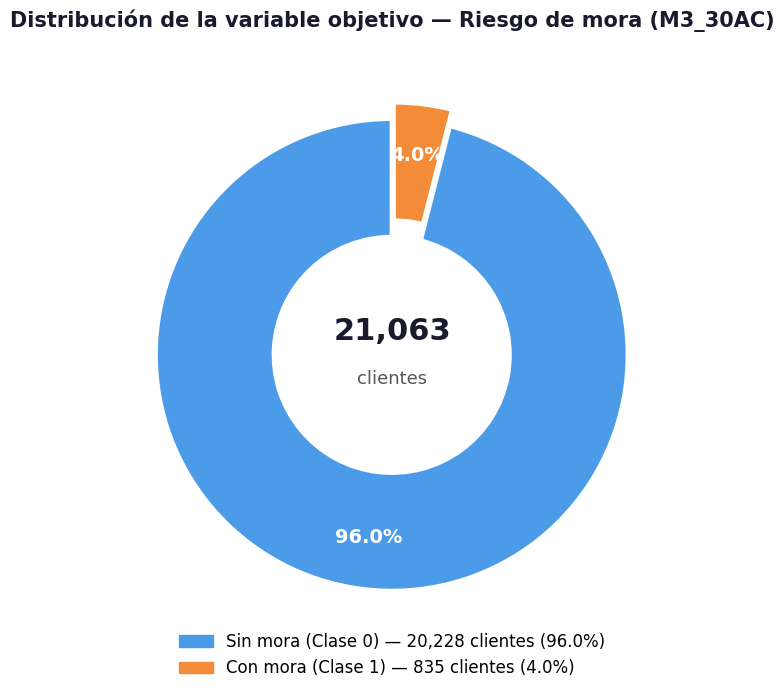

In [22]:
# ── Datos ─────────────────────────────────────────────────────────────────
conteos = df_financiacion['M3_30AC'].value_counts().sort_index()
total   = len(df_financiacion)
valores = [conteos[0], conteos[1]]
colores = ['#4C9BE8', '#F28C38']
labels  = ['Sin mora (Clase 0)', 'Con mora (Clase 1)']

# ── Figura ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    valores,
    labels=None,
    colors=colores,
    autopct='%1.1f%%',
    pctdistance=0.78,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=3),
    explode=(0.02, 0.05),
    textprops=dict(fontsize=14, color='white', fontweight='bold')
)

# ── Texto central ─────────────────────────────────────────────────────────
ax.text(0, 0.08, f'{total:,}', ha='center', va='center',
        fontsize=22, fontweight='bold', color='#1a1a2e')
ax.text(0, -0.12, 'clientes', ha='center', va='center',
        fontsize=13, color='#555')

# ── Leyenda manual ────────────────────────────────────────────────────────
leyenda = [
    mpatches.Patch(color='#4C9BE8',
                   label=f'Sin mora (Clase 0) — {conteos[0]:,} clientes ({conteos[0]/total*100:.1f}%)'),
    mpatches.Patch(color='#F28C38',
                   label=f'Con mora (Clase 1) — {conteos[1]:,} clientes ({conteos[1]/total*100:.1f}%)')
]
ax.legend(handles=leyenda, loc='lower center', bbox_to_anchor=(0.5, -0.08),
          fontsize=12, frameon=False)

# ── Título ────────────────────────────────────────────────────────────────
ax.set_title('Distribución de la variable objetivo — Riesgo de mora (M3_30AC)',
             fontsize=15, fontweight='bold', color='#1a1a2e', pad=20)

plt.tight_layout()
plt.show()

Gráfico 2 — Distribución de densidad por variable y clase:

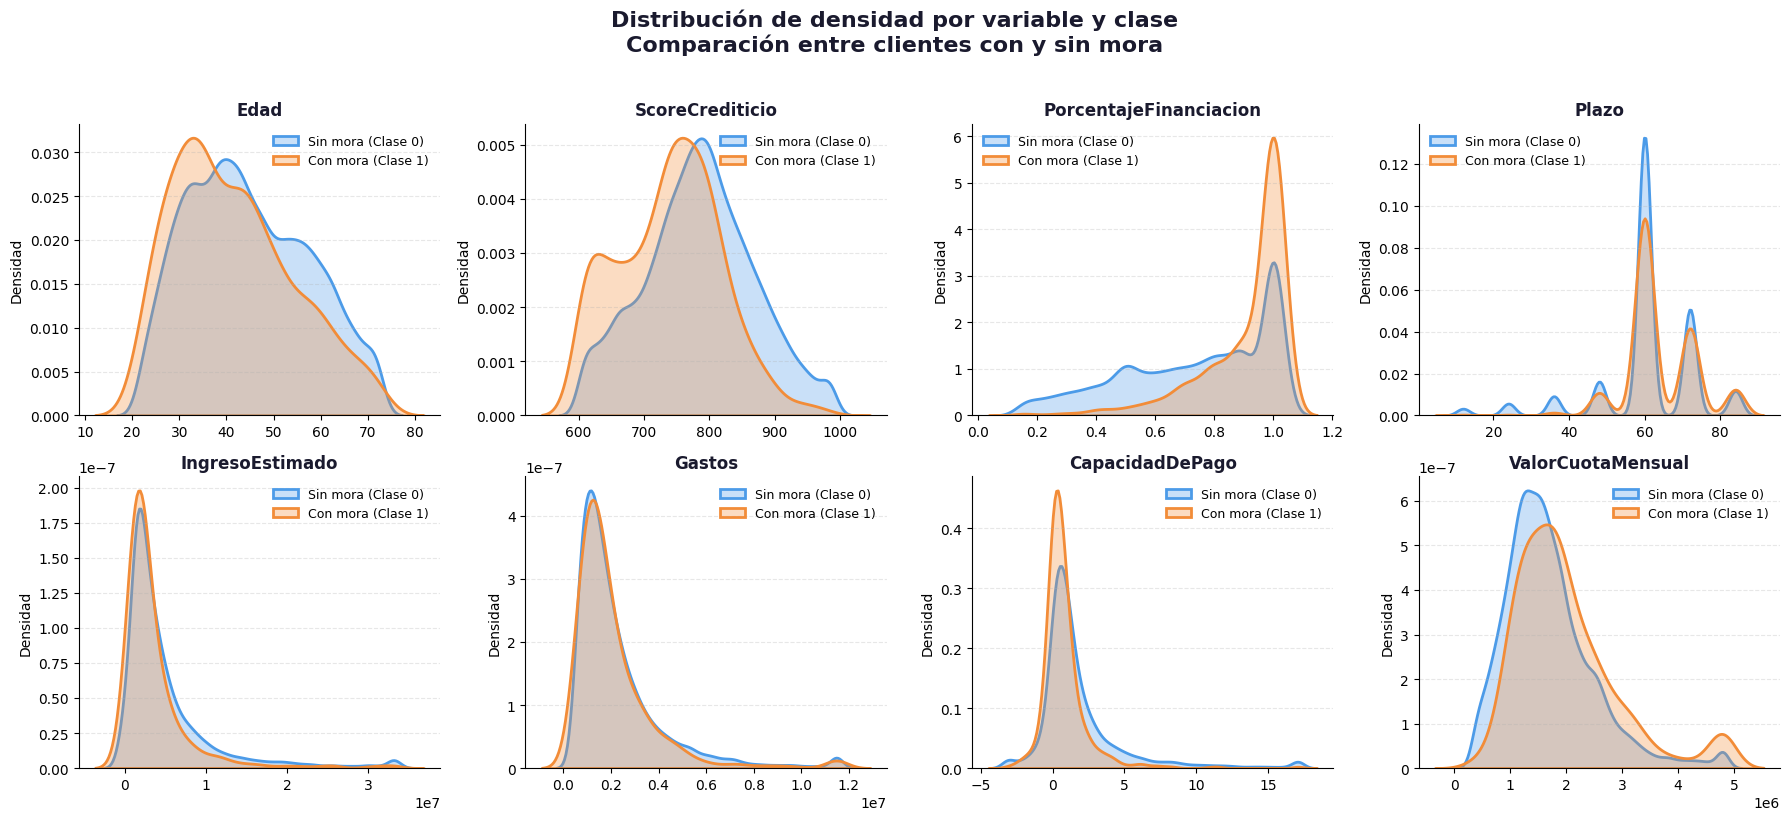

In [23]:
# ── Configuración ─────────────────────────────────────────────────────────
variables  = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
              'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']
colores    = {0: '#4C9BE8', 1: '#F28C38'}
etiquetas  = {0: 'Sin mora (Clase 0)', 1: 'Con mora (Clase 1)'}

# Clipping p1-p99 para visualización limpia
df_plot = df_financiacion.dropna().copy()
for col in variables:
    q01 = df_plot[col].quantile(0.01)
    q99 = df_plot[col].quantile(0.99)
    df_plot[col] = df_plot[col].clip(q01, q99)

# ── Subplots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

fig.suptitle('Distribución de densidad por variable y clase\nComparación entre clientes con y sin mora',
             fontsize=16, fontweight='bold', color='#1a1a2e', y=1.02)

for i, var in enumerate(variables):
    ax = axes[i]
    for clase in [0, 1]:
        subset = df_plot[df_plot['M3_30AC'] == clase][var]
        sns.kdeplot(subset, ax=ax, color=colores[clase],
                    label=etiquetas[clase], fill=True, alpha=0.3,
                    linewidth=2)
    ax.set_title(var, fontsize=12, fontweight='bold', color='#1a1a2e')
    ax.set_xlabel('')
    ax.set_ylabel('Densidad', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('grafico2_densidad.png', dpi=150, bbox_inches='tight')
plt.show()

Gráfico 3 — Boxplot por variable y clase:

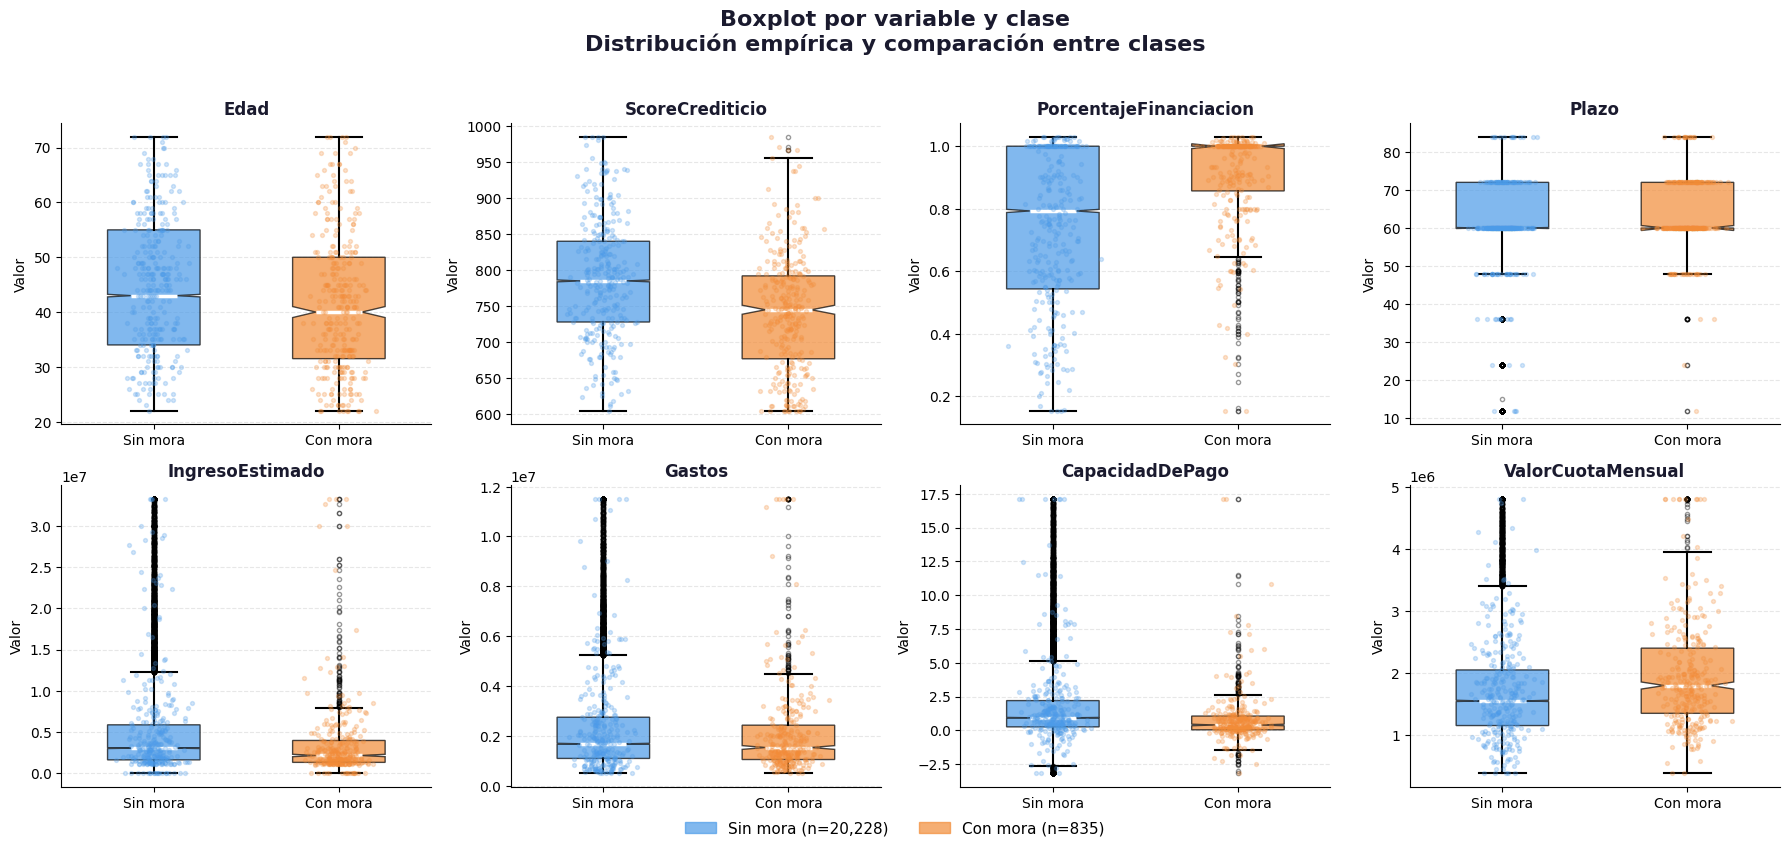

In [24]:
# ── Configuración ─────────────────────────────────────────────────────────
variables  = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
              'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']
colores    = {0: '#4C9BE8', 1: '#F28C38'}
etiquetas  = {0: 'Sin mora', 1: 'Con mora'}

# Clipping p1-p99
df_plot = df_financiacion.dropna().copy()
for col in variables:
    q01 = df_plot[col].quantile(0.01)
    q99 = df_plot[col].quantile(0.99)
    df_plot[col] = df_plot[col].clip(q01, q99)

# ── Subplots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

fig.suptitle('Boxplot por variable y clase\nDistribución empírica y comparación entre clases',
             fontsize=16, fontweight='bold', color='#1a1a2e', y=1.02)

for i, var in enumerate(variables):
    ax = axes[i]

    data_plot = [
        df_plot[df_plot['M3_30AC'] == 0][var].dropna(),
        df_plot[df_plot['M3_30AC'] == 1][var].dropna()
    ]

    bp = ax.boxplot(data_plot,
                    patch_artist=True,
                    notch=True,
                    vert=True,
                    widths=0.5,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))

    # Colores por clase
    for patch, clase in zip(bp['boxes'], [0, 1]):
        patch.set_facecolor(colores[clase])
        patch.set_alpha(0.7)

    # Overlay de puntos
    for j, (datos, clase) in enumerate(zip(data_plot, [0, 1])):
        x = np.random.normal(j + 1, 0.07, size=min(len(datos), 300))
        muestra = datos.sample(min(300, len(datos)), random_state=42)
        ax.scatter(x[:len(muestra)], muestra, alpha=0.25,
                   color=colores[clase], s=8, zorder=3)

    ax.set_title(var, fontsize=12, fontweight='bold', color='#1a1a2e')
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Sin mora', 'Con mora'], fontsize=10)
    ax.set_ylabel('Valor', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

# ── Leyenda global ────────────────────────────────────────────────────────
leyenda = [
    mpatches.Patch(color='#4C9BE8', alpha=0.7, label=f'Sin mora (n={len(df_plot[df_plot["M3_30AC"]==0]):,})'),
    mpatches.Patch(color='#F28C38', alpha=0.7, label=f'Con mora (n={len(df_plot[df_plot["M3_30AC"]==1]):,})')
]
fig.legend(handles=leyenda, loc='lower center', ncol=2,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('grafico3_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Gráfico 4 — Matriz de correlaciones.

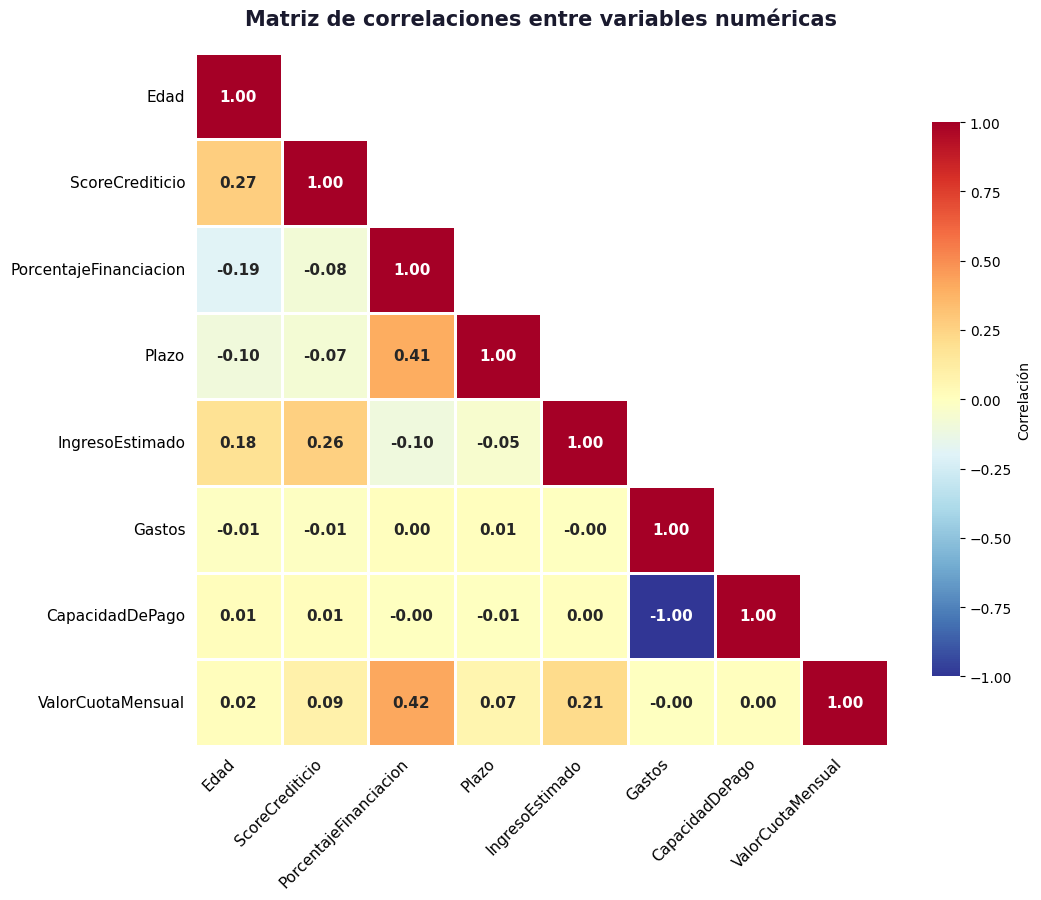

In [25]:
# ── Configuración ─────────────────────────────────────────────────────────
variables_num = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
                 'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']

# Matriz de correlaciones
corr_matrix = df_financiacion[variables_num].corr()

# ── Figura ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

# Máscara triángulo superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.8,
    linecolor='white',
    annot_kws=dict(size=11, fontweight='bold'),
    square=True,
    cbar_kws=dict(shrink=0.8, label='Correlación')
)

# ── Decoración ────────────────────────────────────────────────────────────
ax.set_title('Matriz de correlaciones entre variables numéricas',
             fontsize=15, fontweight='bold', color='#1a1a2e', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
plt.savefig('grafico4_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

Gráfico 5 — Tasa de mora por variable categórica

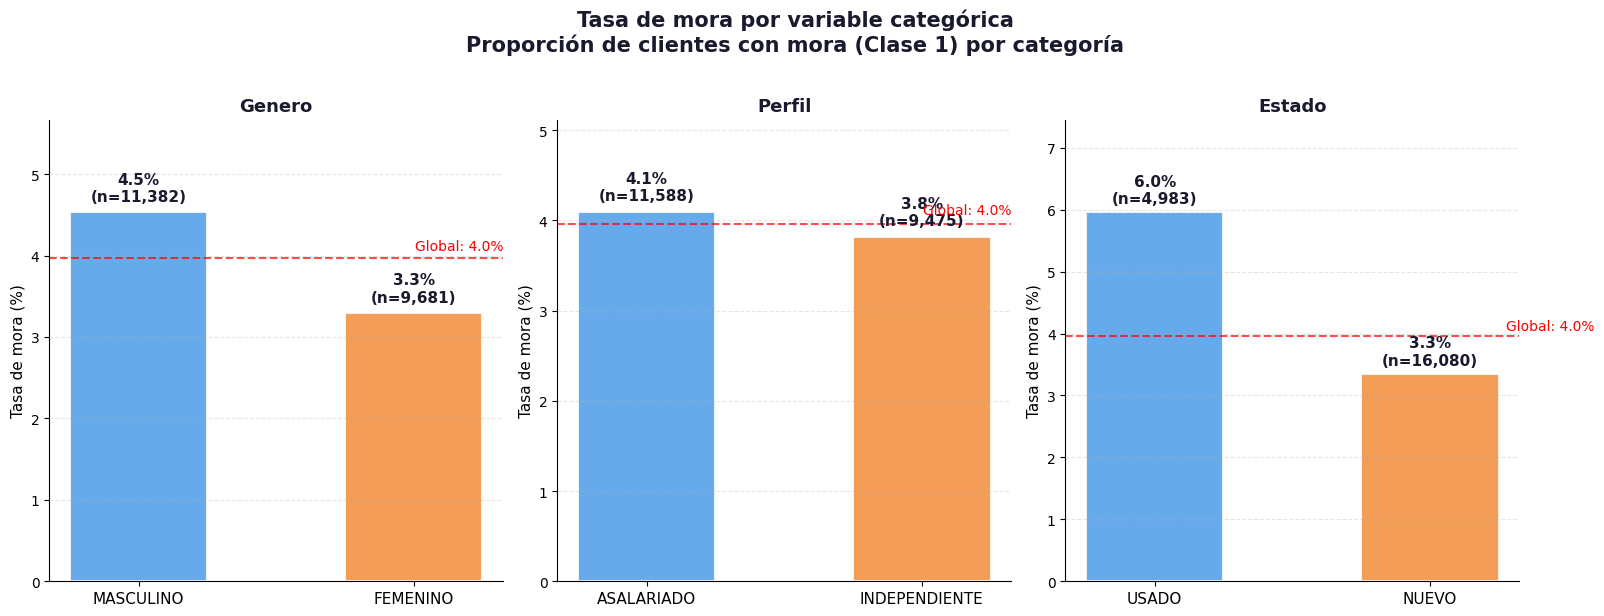

In [26]:
# ── Configuración ─────────────────────────────────────────────────────────
categoricas = ['Genero', 'Perfil', 'Estado']
colores_bar = ['#4C9BE8', '#F28C38']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes = axes.flatten()

fig.suptitle('Tasa de mora por variable categórica\nProporción de clientes con mora (Clase 1) por categoría',
             fontsize=15, fontweight='bold', color='#1a1a2e', y=1.02)

for i, var in enumerate(categoricas):
    ax = axes[i]

    # Calcular tasa de mora por categoría
    resumen = df_financiacion.groupby(var)['M3_30AC'].agg(['mean', 'count']).reset_index()
    resumen.columns = [var, 'tasa_mora', 'total']
    resumen['tasa_mora'] = resumen['tasa_mora'] * 100
    resumen = resumen.sort_values('tasa_mora', ascending=False)

    # Barras
    bars = ax.bar(resumen[var], resumen['tasa_mora'],
                  color=colores_bar[:len(resumen)],
                  edgecolor='white', linewidth=1.5,
                  alpha=0.85, width=0.5)

    # Etiquetas encima de cada barra
    for bar, (_, row) in zip(bars, resumen.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.1,
                f"{row['tasa_mora']:.1f}%\n(n={int(row['total']):,})",
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                color='#1a1a2e')

    # Línea de tasa global
    tasa_global = df_financiacion['M3_30AC'].mean() * 100
    ax.axhline(tasa_global, color='red', linestyle='--',
               linewidth=1.5, alpha=0.7)
    ax.text(ax.get_xlim()[1] if i < 2 else len(resumen) - 0.4,
            tasa_global + 0.1,
            f'Global: {tasa_global:.1f}%',
            color='red', fontsize=10, ha='right')

    ax.set_title(var, fontsize=13, fontweight='bold', color='#1a1a2e')
    ax.set_xlabel('')
    ax.set_ylabel('Tasa de mora (%)', fontsize=11)
    ax.set_ylim(0, resumen['tasa_mora'].max() * 1.25)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.savefig('grafico5_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

Gráfico 6 — ECDF por variable y clase

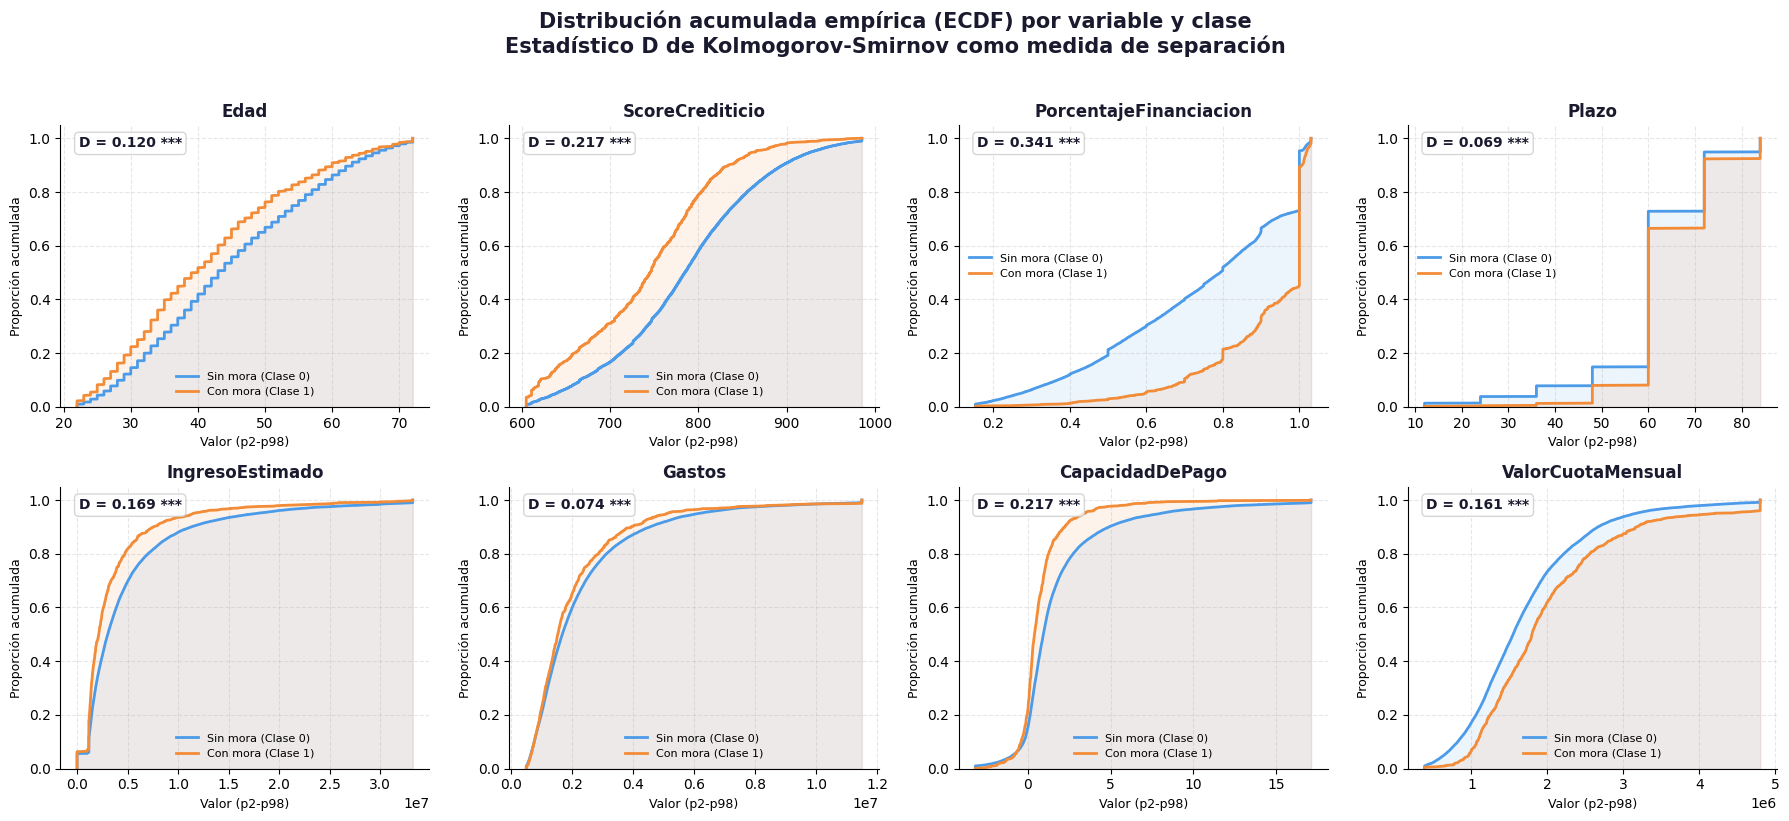

In [27]:
from scipy import stats

# ── Configuración ─────────────────────────────────────────────────────────
variables  = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
              'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']
colores    = {0: '#4C9BE8', 1: '#F28C38'}
etiquetas  = {0: 'Sin mora (Clase 0)', 1: 'Con mora (Clase 1)'}

# Clipping p1-p99
df_plot = df_financiacion.dropna().copy()
for col in variables:
    q01 = df_plot[col].quantile(0.01)
    q99 = df_plot[col].quantile(0.99)
    df_plot[col] = df_plot[col].clip(q01, q99)

# ── Subplots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

fig.suptitle('Distribución acumulada empírica (ECDF) por variable y clase\nEstadístico D de Kolmogorov-Smirnov como medida de separación',
             fontsize=15, fontweight='bold', color='#1a1a2e', y=1.02)

for i, var in enumerate(variables):
    ax = axes[i]

    clase0 = df_plot[df_plot['M3_30AC'] == 0][var].dropna().sort_values()
    clase1 = df_plot[df_plot['M3_30AC'] == 1][var].dropna().sort_values()

    # ECDF clase 0
    y0 = np.arange(1, len(clase0) + 1) / len(clase0)
    ax.plot(clase0, y0, color=colores[0], linewidth=2,
            label=etiquetas[0])
    ax.fill_between(clase0, y0, alpha=0.1, color=colores[0])

    # ECDF clase 1
    y1 = np.arange(1, len(clase1) + 1) / len(clase1)
    ax.plot(clase1, y1, color=colores[1], linewidth=2,
            label=etiquetas[1])
    ax.fill_between(clase1, y1, alpha=0.1, color=colores[1])

    # Estadístico KS
    ks_stat, p_value = stats.ks_2samp(clase0, clase1)
    sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
    ax.text(0.05, 0.92, f'D = {ks_stat:.3f} {sig}',
            transform=ax.transAxes, fontsize=10,
            fontweight='bold', color='#1a1a2e',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#ccc', alpha=0.8))

    ax.set_title(var, fontsize=12, fontweight='bold', color='#1a1a2e')
    ax.set_xlabel('Valor (p2-p98)', fontsize=9)
    ax.set_ylabel('Proporción acumulada', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=8, frameon=False)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('grafico6_ecdf.png', dpi=150, bbox_inches='tight')
plt.show()

Gráfico 7 — Deciles por variable:

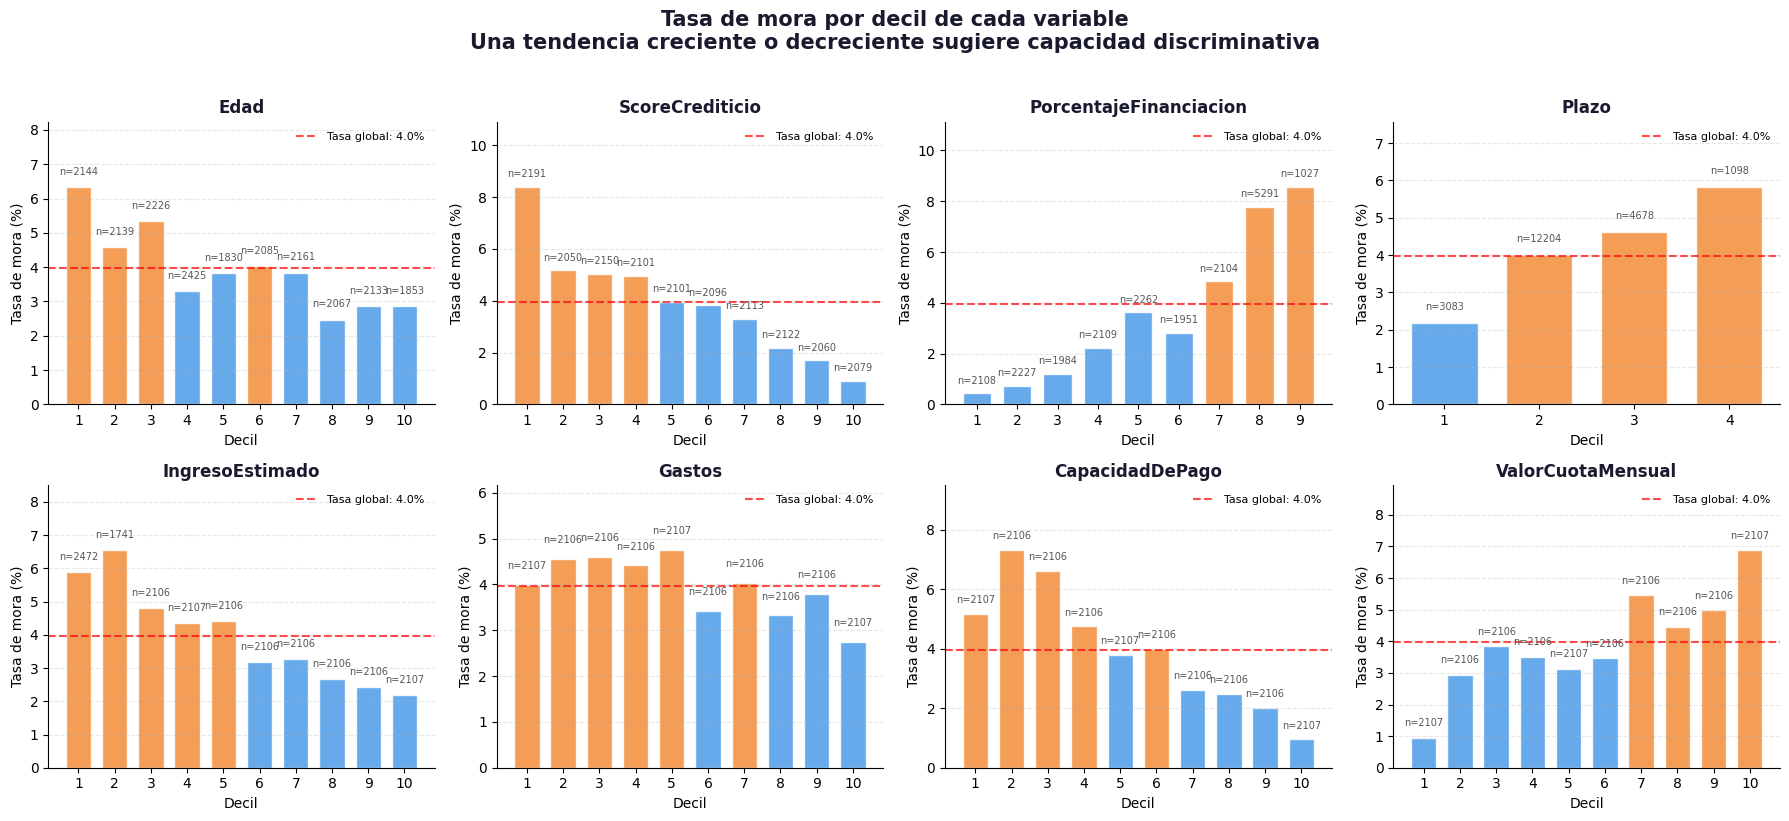

In [28]:
# ── Configuración ─────────────────────────────────────────────────────────
variables  = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
              'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']

df_plot = df_financiacion.dropna().copy()
tasa_global = df_plot['M3_30AC'].mean()

# ── Subplots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

fig.suptitle('Tasa de mora por decil de cada variable\nUna tendencia creciente o decreciente sugiere capacidad discriminativa',
             fontsize=15, fontweight='bold', color='#1a1a2e', y=1.02)

for i, var in enumerate(variables):
    ax = axes[i]

    # Calcular deciles
    df_plot['decil'] = pd.qcut(df_plot[var], q=10,
                                labels=False, duplicates='drop') + 1
    resumen = df_plot.groupby('decil')['M3_30AC'].agg(['mean', 'count']).reset_index()
    resumen.columns = ['decil', 'tasa_mora', 'n']
    resumen['tasa_mora'] = resumen['tasa_mora'] * 100

    # Barras con gradiente de color según tasa
    colores_decil = ['#F28C38' if t > tasa_global * 100 else '#4C9BE8'
                     for t in resumen['tasa_mora']]

    bars = ax.bar(resumen['decil'], resumen['tasa_mora'],
                  color=colores_decil, edgecolor='white',
                  linewidth=1, alpha=0.85, width=0.7)

    # Etiqueta n encima de cada barra
    for bar, (_, row) in zip(bars, resumen.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f"n={int(row['n'])}",
                ha='center', va='bottom', fontsize=7,
                color='#555')

    # Línea tasa global
    ax.axhline(tasa_global * 100, color='red', linestyle='--',
               linewidth=1.5, alpha=0.7,
               label=f'Tasa global: {tasa_global*100:.1f}%')

    ax.set_title(var, fontsize=12, fontweight='bold', color='#1a1a2e')
    ax.set_xlabel('Decil', fontsize=10)
    ax.set_ylabel('Tasa de mora (%)', fontsize=10)
    ax.set_xticks(resumen['decil'])
    ax.set_ylim(0, resumen['tasa_mora'].max() * 1.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig('grafico7_deciles.png', dpi=150, bbox_inches='tight')
plt.show()

## MODELO BASE (Con la base de datos balanceaada 1;2 incluyendo todas las variables)

En esta sección, vamos a codificar el modelo incluyendo todas las variables de la base de datos, excluyendo la variable "Caso" la cual es irrelevante en este contexto

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
# ── 1. Separar variables predictoras y objetivo ───────────────────────────
X = df_balanceado.drop(columns=['M3_30AC'])
y = df_balanceado['M3_30AC']

In [31]:
# ── 2. Escalar variables numéricas ────────────────────────────────────────
numericas = ['Edad', 'ScoreCrediticio', 'PorcentajeFinanciacion', 'Plazo',
             'IngresoEstimado', 'Gastos', 'CapacidadDePago', 'ValorCuotaMensual']

scaler = StandardScaler()
X[numericas] = scaler.fit_transform(X[numericas])

In [32]:

# ── 3. División train/test (70% - 30%) ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"\nDistribución train:\n{y_train.value_counts(normalize=True).round(4)*100}")
print(f"\nDistribución test:\n{y_test.value_counts(normalize=True).round(4)*100}")

Train: (1753, 11) | Test: (752, 11)

Distribución train:
M3_30AC
0    66.69
1    33.31
Name: proportion, dtype: float64

Distribución test:
M3_30AC
0    66.62
1    33.38
Name: proportion, dtype: float64


In [33]:
# ── 4. Construcción del modelo base ───────────────────────────────────────
model_base = Sequential()

model_base.add(InputLayer(shape=(X_train.shape[1],)))
model_base.add(Dense(18, activation='relu'))
model_base.add(Dropout(0.2))
model_base.add(Dense(18, activation='relu'))
model_base.add(Dropout(0.2))
model_base.add(Dense(1, activation='sigmoid'))

model_base.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

model_base.summary()

# ── 5. Entrenamiento ──────────────────────────────────────────────────────
callback = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history_base = model_base.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[callback],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 18)             │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            19 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577 (2.25 KB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6691 - loss: 0.5977 - val_accuracy: 0.7021 - val_loss: 0.5533
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7096 - loss: 0.5348 - val_accuracy: 0.7114 - val_loss: 0.5464
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7250 - loss: 0.5280 - val_accuracy: 0.7168 - val_loss: 0.5479
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7188 - loss: 0.5230 - val_accuracy: 0.6968 - val_loss: 0.5495
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7245 - loss: 0.5141 - val_accuracy: 0.6862 - val_loss: 0.5609
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7210 - loss: 0.5147 - val_accuracy: 0.7141 - val_loss: 0.5431
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7250 - loss: 0.5141 - val_accuracy: 0.7154 - val_loss: 0.5446
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7279 - loss: 0.5110 - val_accuracy: 0.7

In [34]:
# ── 6. Predicciones con umbral 0.5 ────────────────────────────────────────
y_prob_train = model_base.predict(X_train, verbose=0).flatten()
y_prob_test  = model_base.predict(X_test, verbose=0).flatten()

umbral = 0.5
y_pred_train = np.where(y_prob_train >= umbral, 1, 0)
y_pred_test  = np.where(y_prob_test  >= umbral, 1, 0)

# ── 7. Métricas ───────────────────────────────────────────────────────────
print("=" * 50)
print("REPORTE DE CLASIFICACIÓN — TRAIN")
print("=" * 50)
print(classification_report(y_train, y_pred_train))

print("=" * 50)
print("REPORTE DE CLASIFICACIÓN — TEST")
print("=" * 50)
print(classification_report(y_test, y_pred_test))

REPORTE DE CLASIFICACIÓN — TRAIN
              precision    recall  f1-score   support

           0       0.80      0.84      0.82      1169
           1       0.64      0.57      0.60       584

    accuracy                           0.75      1753
   macro avg       0.72      0.71      0.71      1753
weighted avg       0.74      0.75      0.75      1753

REPORTE DE CLASIFICACIÓN — TEST
              precision    recall  f1-score   support

           0       0.77      0.82      0.79       501
           1       0.58      0.51      0.55       251

    accuracy                           0.72       752
   macro avg       0.68      0.67      0.67       752
weighted avg       0.71      0.72      0.71       752



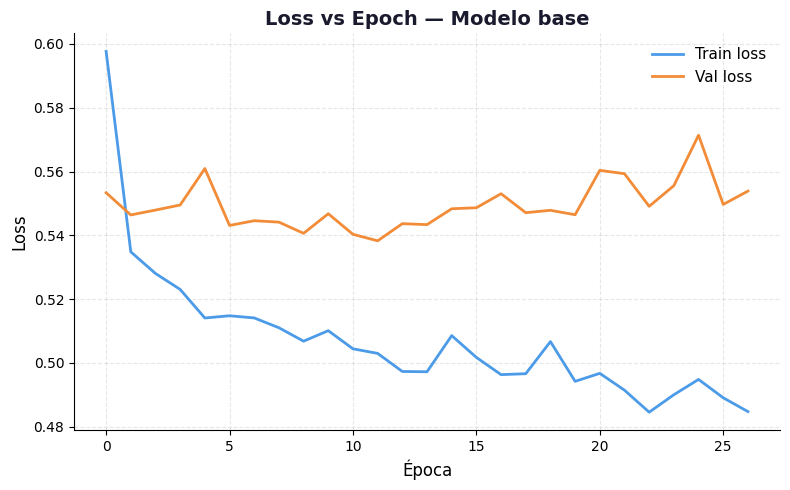

In [35]:
# ── 8. Loss vs Epoch ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(history_base.history['loss'],     color='#4C9BE8', linewidth=2, label='Train loss')
ax.plot(history_base.history['val_loss'], color='#F28C38', linewidth=2, label='Val loss')

ax.set_title('Loss vs Epoch — Modelo base', fontsize=14, fontweight='bold', color='#1a1a2e')
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(fontsize=11, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('loss_modelo_base.png', dpi=150, bbox_inches='tight')
plt.show()

## OPTIMIZACIÓN DE HIPERPARAMETROS EN EL MODELO BASE

In [36]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score
import itertools

# ── Hiperparámetros a explorar ────────────────────────────────────────────
param_grid = {
    'neuronas'   : [8, 16, 32],
    'activacion' : ['relu', 'elu'],
    'lr'         : [0.001, 0.01, 0.1],
    'optimizer'  : ['adam', 'rmsprop'],
    'batch_size' : [32, 64],
    'dropout'    : [0.2, 0.3]
}

# ── Generar todas las combinaciones ───────────────────────────────────────
keys         = list(param_grid.keys())
values       = list(param_grid.values())
combinaciones = list(itertools.product(*values))
print(f"Total combinaciones a evaluar: {len(combinaciones)}")

Total combinaciones a evaluar: 144


In [37]:
from tensorflow.keras.optimizers import RMSprop

# ── Búsqueda de hiperparámetros ───────────────────────────────────────────
resultados = []

for i, combo in enumerate(combinaciones):
    params = dict(zip(keys, combo))
    
    try:
        # Construir modelo
        model_temp = Sequential()
        model_temp.add(InputLayer(shape=(X_train.shape[1],)))
        model_temp.add(Dense(params['neuronas'], activation=params['activacion']))
        model_temp.add(Dropout(params['dropout']))
        model_temp.add(Dense(params['neuronas'], activation=params['activacion']))
        model_temp.add(Dropout(params['dropout']))
        model_temp.add(Dense(1, activation='sigmoid'))

        # Optimizador
        if params['optimizer'] == 'adam':
            opt = Adam(learning_rate=params['lr'])
        else:
            opt = RMSprop(learning_rate=params['lr'])

        model_temp.compile(
            loss='binary_crossentropy',
            optimizer=opt,
            metrics=['accuracy']
        )

        # Entrenamiento
        cb = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True)

        model_temp.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=100,
            batch_size=params['batch_size'],
            callbacks=[cb],
            verbose=0
        )

        # Evaluación
        y_prob_temp = model_temp.predict(X_test, verbose=0).flatten()
        y_pred_temp = np.where(y_prob_temp >= 0.5, 1, 0)
        recall_1    = recall_score(y_test, y_pred_temp, pos_label=1)

        resultados.append({**params, 'recall_clase1': recall_1})

        if (i + 1) % 20 == 0:
            print(f"Progreso: {i+1}/144 combinaciones evaluadas...")

    except Exception as e:
        resultados.append({**params, 'recall_clase1': 0})

# ── Resultados ────────────────────────────────────────────────────────────
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('recall_clase1', ascending=False)

print("\n✓ Búsqueda completada")
print("\nTop 10 mejores configuraciones:")
print(df_resultados.head(10).to_string(index=False))

print(f"\n🏆 Mejor configuración:")
mejor = df_resultados.iloc[0]
print(mejor)

Progreso: 20/144 combinaciones evaluadas...
Progreso: 40/144 combinaciones evaluadas...
Progreso: 60/144 combinaciones evaluadas...
Progreso: 80/144 combinaciones evaluadas...
Progreso: 100/144 combinaciones evaluadas...
Progreso: 120/144 combinaciones evaluadas...
Progreso: 140/144 combinaciones evaluadas...

✓ Búsqueda completada

Top 10 mejores configuraciones:
 neuronas activacion    lr optimizer  batch_size  dropout  recall_clase1
       32        elu 0.100      adam          64      0.3       0.749004
       16        elu 0.100      adam          32      0.2       0.629482
        8        elu 0.100   rmsprop          32      0.2       0.629482
        8       relu 0.010   rmsprop          64      0.3       0.609562
        8        elu 0.100   rmsprop          64      0.2       0.605578
       16        elu 0.100      adam          64      0.2       0.597610
        8        elu 0.100      adam          64      0.3       0.593625
        8        elu 0.100      adam          64 

## MODELO CON LOS HIPERPARAMETROS OPTIMIZADOS

In [38]:
# ── Modelo optimizado estable ─────────────────────────────────────────────
model_opt = Sequential()

model_opt.add(InputLayer(shape=(X_train.shape[1],)))
model_opt.add(Dense(32, activation='elu'))
model_opt.add(Dropout(0.2))
model_opt.add(Dense(32, activation='elu'))
model_opt.add(Dropout(0.2))
model_opt.add(Dense(1, activation='sigmoid'))

model_opt.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=0.01),
    metrics=['accuracy']
)

cb_opt = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history_opt = model_opt.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    callbacks=[cb_opt],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.6880 - loss: 0.5692 - val_accuracy: 0.7008 - val_loss: 0.5588
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7028 - loss: 0.5363 - val_accuracy: 0.6875 - val_loss: 0.5733
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7250 - loss: 0.5336 - val_accuracy: 0.6995 - val_loss: 0.5512
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7222 - loss: 0.5281 - val_accuracy: 0.7035 - val_loss: 0.5481
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7268 - loss: 0.5207 - val_accuracy: 0.7141 - val_loss: 0.5506
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7359 - loss: 0.5115 - val_accuracy: 0.7074 - val_loss: 0.5433
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7222 - loss: 0.5159 - val_accuracy: 0.6928 - val_loss: 0.5563
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7250 - loss: 0.5115 - val_accuracy: 0.

In [39]:
# ── Predicciones modelo optimizado ────────────────────────────────────────
y_prob_train_opt = model_opt.predict(X_train, verbose=0).flatten()
y_prob_test_opt  = model_opt.predict(X_test, verbose=0).flatten()

umbral = 0.5
y_pred_train_opt = np.where(y_prob_train_opt >= umbral, 1, 0)
y_pred_test_opt  = np.where(y_prob_test_opt  >= umbral, 1, 0)

# ── Métricas ──────────────────────────────────────────────────────────────
print("=" * 50)
print("REPORTE — TRAIN")
print("=" * 50)
print(classification_report(y_train, y_pred_train_opt))

print("=" * 50)
print("REPORTE — TEST")
print("=" * 50)
print(classification_report(y_test, y_pred_test_opt))

REPORTE — TRAIN
              precision    recall  f1-score   support

           0       0.79      0.85      0.82      1169
           1       0.66      0.55      0.60       584

    accuracy                           0.75      1753
   macro avg       0.72      0.70      0.71      1753
weighted avg       0.75      0.75      0.75      1753

REPORTE — TEST
              precision    recall  f1-score   support

           0       0.77      0.82      0.79       501
           1       0.58      0.50      0.54       251

    accuracy                           0.71       752
   macro avg       0.68      0.66      0.67       752
weighted avg       0.71      0.71      0.71       752



## GRAFICOS DE LAS METRICAS
Util para observar si graficamente hay algun tipo de sobreajuste en el modelo

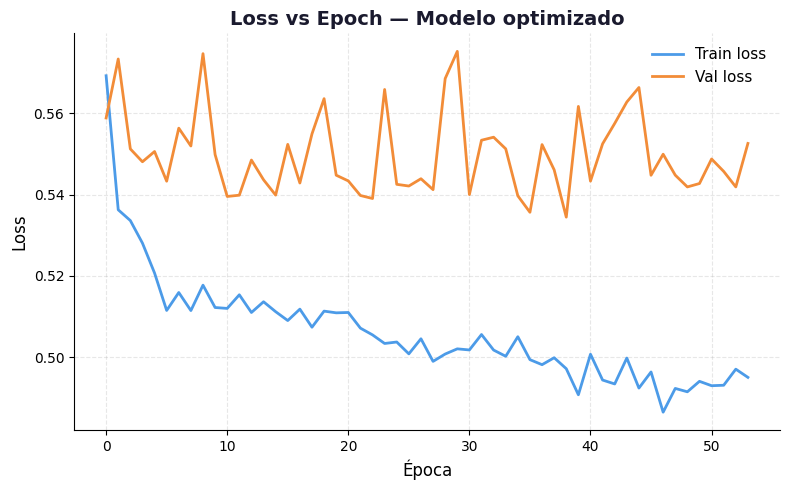

In [40]:
# ── Loss vs Epoch ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_opt.history['loss'],     color='#4C9BE8', linewidth=2, label='Train loss')
ax.plot(history_opt.history['val_loss'], color='#F28C38', linewidth=2, label='Val loss')
ax.set_title('Loss vs Epoch — Modelo optimizado', fontsize=14, fontweight='bold', color='#1a1a2e')
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(fontsize=11, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('loss_modelo_opt.png', dpi=150, bbox_inches='tight')
plt.show()

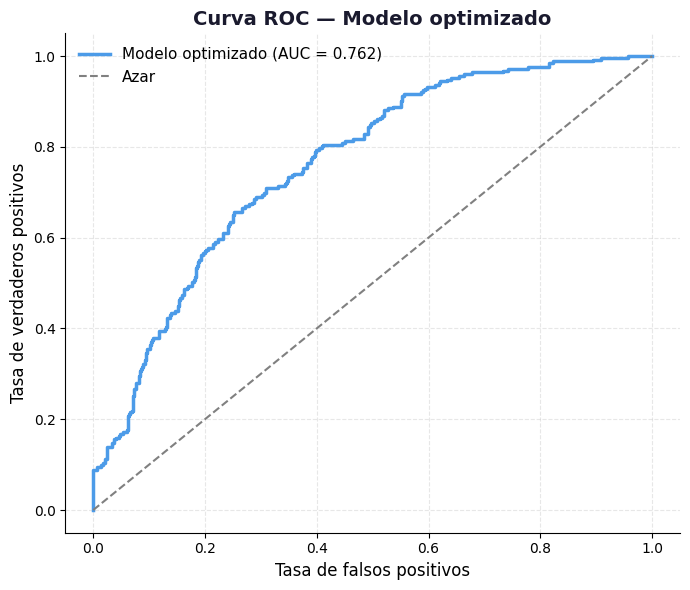

In [41]:
# ── Curva ROC ─────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob_test_opt)
auc_opt     = roc_auc_score(y_test, y_prob_test_opt)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#4C9BE8', linewidth=2.5, label=f'Modelo optimizado (AUC = {auc_opt:.3f})')
ax.plot([0,1], [0,1], color='gray', linestyle='--', linewidth=1.5, label='Azar')
ax.set_title('Curva ROC — Modelo optimizado', fontsize=14, fontweight='bold', color='#1a1a2e')
ax.set_xlabel('Tasa de falsos positivos', fontsize=12)
ax.set_ylabel('Tasa de verdaderos positivos', fontsize=12)
ax.legend(fontsize=11, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('roc_modelo_opt.png', dpi=150, bbox_inches='tight')
plt.show()

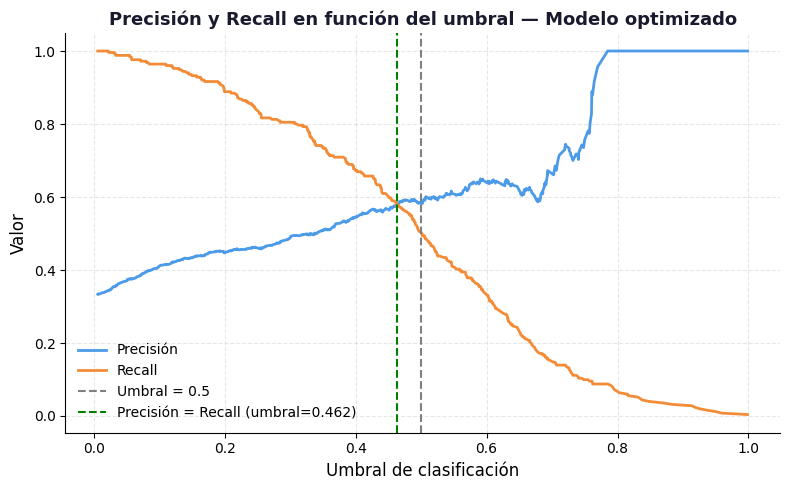

In [43]:
from sklearn.metrics import precision_recall_curve

# ── Curva Precision-Recall ────────────────────────────────────────────────
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_prob_test_opt)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precision_curve[:-1], color='#4C9BE8', linewidth=2, label='Precisión')
ax.plot(thresholds, recall_curve[:-1],    color='#F28C38', linewidth=2, label='Recall')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, label='Umbral = 0.5')

# Punto donde precision = recall
diff = np.abs(precision_curve[:-1] - recall_curve[:-1])
idx  = np.argmin(diff)
ax.axvline(x=thresholds[idx], color='green', linestyle='--', linewidth=1.5,
           label=f'Precisión = Recall (umbral={thresholds[idx]:.3f})')

ax.set_title('Precisión y Recall en función del umbral — Modelo optimizado',
             fontsize=13, fontweight='bold', color='#1a1a2e')
ax.set_xlabel('Umbral de clasificación', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.legend(fontsize=10, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('pr_modelo_opt.png', dpi=150, bbox_inches='tight')
plt.show()

## METRICAS NUMERICAS DEL MODELO OPTIMIZADO

In [44]:
print("=" * 50)
print("REPORTE — TRAIN — Modelo optimizado")
print("=" * 50)
print(classification_report(y_train, y_pred_train_opt))

print("=" * 50)
print("REPORTE — TEST — Modelo optimizado")
print("=" * 50)
print(classification_report(y_test, y_pred_test_opt))

REPORTE — TRAIN — Modelo optimizado
              precision    recall  f1-score   support

           0       0.79      0.85      0.82      1169
           1       0.66      0.55      0.60       584

    accuracy                           0.75      1753
   macro avg       0.72      0.70      0.71      1753
weighted avg       0.75      0.75      0.75      1753

REPORTE — TEST — Modelo optimizado
              precision    recall  f1-score   support

           0       0.77      0.82      0.79       501
           1       0.58      0.50      0.54       251

    accuracy                           0.71       752
   macro avg       0.68      0.66      0.67       752
weighted avg       0.71      0.71      0.71       752



## MODELO CON VARIABLES SELECCIONADAS

In [45]:
# ── 1. Selección de variables ─────────────────────────────────────────────
variables_seleccionadas = ['ScoreCrediticio', 'PorcentajeFinanciacion', 
                           'CapacidadDePago', 'Edad', 'Estado',
                           'IngresoEstimado', 'ValorCuotaMensual']

X2 = df_balanceado[variables_seleccionadas].copy()
y2 = df_balanceado['M3_30AC']

# ── 2. Escalar variables numéricas ────────────────────────────────────────
numericas_2 = ['ScoreCrediticio', 'PorcentajeFinanciacion', 'CapacidadDePago',
               'Edad', 'IngresoEstimado', 'ValorCuotaMensual']

scaler2 = StandardScaler()
X2[numericas_2] = scaler2.fit_transform(X2[numericas_2])

# ── 3. División train/test ────────────────────────────────────────────────
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2
)

print(f"Variables seleccionadas: {variables_seleccionadas}")
print(f"Train: {X2_train.shape} | Test: {X2_test.shape}")

# ── 4. Construcción del modelo ────────────────────────────────────────────
model_sel = Sequential()

model_sel.add(InputLayer(shape=(X2_train.shape[1],)))
model_sel.add(Dense(32, activation='elu'))
model_sel.add(Dropout(0.2))
model_sel.add(Dense(32, activation='elu'))
model_sel.add(Dropout(0.2))
model_sel.add(Dense(1, activation='sigmoid'))

model_sel.compile(
    loss='binary_crossentropy',
    optimizer=RMSprop(learning_rate=0.01),
    metrics=['accuracy']
)

cb_sel = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# ── 5. Entrenamiento ──────────────────────────────────────────────────────
history_sel = model_sel.fit(
    X2_train, y2_train,
    validation_data=(X2_test, y2_test),
    epochs=100,
    batch_size=64,
    callbacks=[cb_sel],
    verbose=1
)

Variables seleccionadas: ['ScoreCrediticio', 'PorcentajeFinanciacion', 'CapacidadDePago', 'Edad', 'Estado', 'IngresoEstimado', 'ValorCuotaMensual']
Train: (1753, 7) | Test: (752, 7)
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7068 - loss: 0.5518 - val_accuracy: 0.7008 - val_loss: 0.5623
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7216 - loss: 0.5267 - val_accuracy: 0.6888 - val_loss: 0.5546
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7222 - loss: 0.5211 - val_accuracy: 0.6809 - val_loss: 0.5778
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7222 - loss: 0.5216 - val_accuracy: 0.7101 - val_loss: 0.5536
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7273 - loss: 0.5265 - val_accuracy: 0.6995 - val_loss: 0.5536
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7142 - loss: 0.5251 - val_accuracy: 0.6995 - val_loss: 0.5489
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

In [46]:
# ── Predicciones modelo seleccionado ──────────────────────────────────────
y_prob_train_sel = model_sel.predict(X2_train, verbose=0).flatten()
y_prob_test_sel  = model_sel.predict(X2_test, verbose=0).flatten()

umbral = 0.5
y_pred_train_sel = np.where(y_prob_train_sel >= umbral, 1, 0)
y_pred_test_sel  = np.where(y_prob_test_sel  >= umbral, 1, 0)

# ── Métricas ──────────────────────────────────────────────────────────────
print("=" * 50)
print("REPORTE — TRAIN — Modelo variables seleccionadas")
print("=" * 50)
print(classification_report(y2_train, y_pred_train_sel))

print("=" * 50)
print("REPORTE — TEST — Modelo variables seleccionadas")
print("=" * 50)
print(classification_report(y2_test, y_pred_test_sel))

REPORTE — TRAIN — Modelo variables seleccionadas
              precision    recall  f1-score   support

           0       0.76      0.85      0.81      1169
           1       0.61      0.47      0.53       584

    accuracy                           0.73      1753
   macro avg       0.69      0.66      0.67      1753
weighted avg       0.71      0.73      0.71      1753

REPORTE — TEST — Modelo variables seleccionadas
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       501
           1       0.57      0.46      0.51       251

    accuracy                           0.71       752
   macro avg       0.66      0.64      0.65       752
weighted avg       0.69      0.71      0.70       752



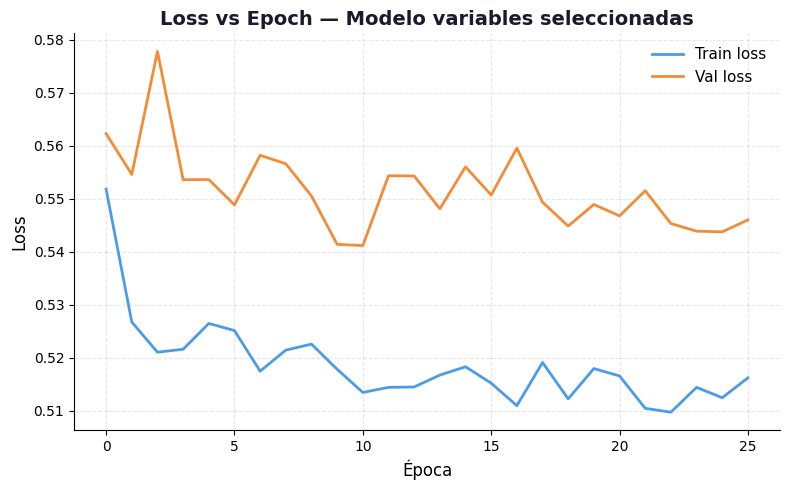

In [47]:
# ── Loss vs Epoch ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_sel.history['loss'],     color='#4C9BE8', linewidth=2, label='Train loss')
ax.plot(history_sel.history['val_loss'], color='#F28C38', linewidth=2, label='Val loss')
ax.set_title('Loss vs Epoch — Modelo variables seleccionadas',
             fontsize=14, fontweight='bold', color='#1a1a2e')
ax.set_xlabel('Época', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend(fontsize=11, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('loss_modelo_sel.png', dpi=150, bbox_inches='tight')
plt.show()

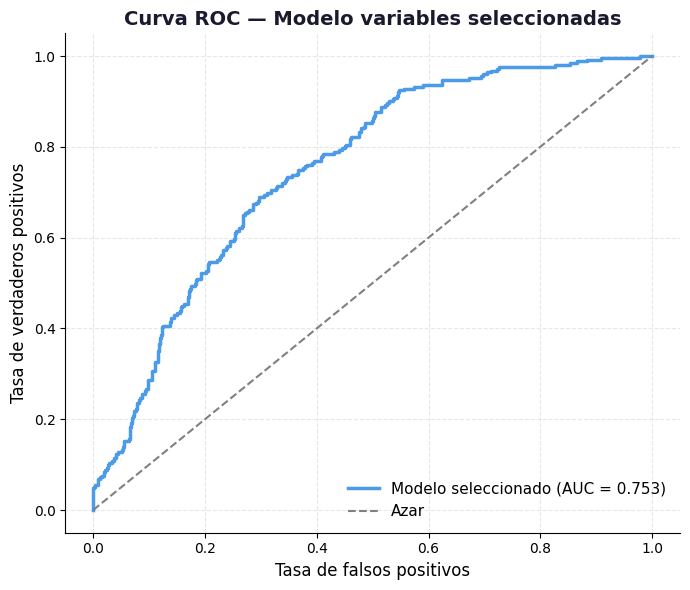

In [48]:
# ── Curva ROC ─────────────────────────────────────────────────────────────
fpr_sel, tpr_sel, _ = roc_curve(y2_test, y_prob_test_sel)
auc_sel             = roc_auc_score(y2_test, y_prob_test_sel)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_sel, tpr_sel, color='#4C9BE8', linewidth=2.5,
        label=f'Modelo seleccionado (AUC = {auc_sel:.3f})')
ax.plot([0,1], [0,1], color='gray', linestyle='--', linewidth=1.5, label='Azar')
ax.set_title('Curva ROC — Modelo variables seleccionadas',
             fontsize=14, fontweight='bold', color='#1a1a2e')
ax.set_xlabel('Tasa de falsos positivos', fontsize=12)
ax.set_ylabel('Tasa de verdaderos positivos', fontsize=12)
ax.legend(fontsize=11, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('roc_modelo_sel.png', dpi=150, bbox_inches='tight')
plt.show()

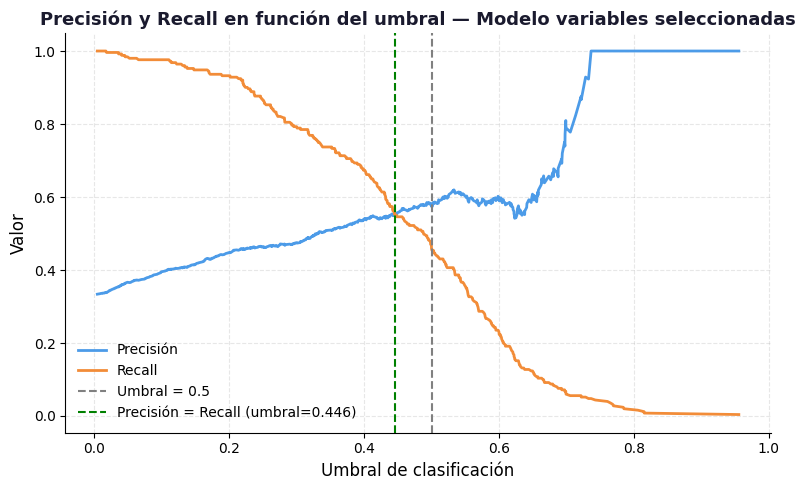

In [49]:
# ── Curva Precision-Recall ────────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve

precision_curve_sel, recall_curve_sel, thresholds_sel = precision_recall_curve(
    y2_test, y_prob_test_sel)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds_sel, precision_curve_sel[:-1], color='#4C9BE8',
        linewidth=2, label='Precisión')
ax.plot(thresholds_sel, recall_curve_sel[:-1],    color='#F28C38',
        linewidth=2, label='Recall')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5,
           label='Umbral = 0.5')

diff_sel = np.abs(precision_curve_sel[:-1] - recall_curve_sel[:-1])
idx_sel  = np.argmin(diff_sel)
ax.axvline(x=thresholds_sel[idx_sel], color='green', linestyle='--',
           linewidth=1.5,
           label=f'Precisión = Recall (umbral={thresholds_sel[idx_sel]:.3f})')

ax.set_title('Precisión y Recall en función del umbral — Modelo variables seleccionadas',
             fontsize=13, fontweight='bold', color='#1a1a2e')
ax.set_xlabel('Umbral de clasificación', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.legend(fontsize=10, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('pr_modelo_sel.png', dpi=150, bbox_inches='tight')
plt.show()